# Case Study: Rate My Answer!

**By: Dr. Reza Mousavi, University of Virginia, mousavi@virginia.edu**

In this notebook, we pre-process answers posted in a health forum and create classifiers that predict whether an answer is posted by a medical expert (physician) or not.

## 1. Import packages and load the data:

In [1]:
# %%capture --no-display
# !pip install spacy # install spaCy
# !pip install tqdm # install tqdm package to display the progress
# !pip uninstall tensorflow -y
# !pip install tensorflow # install tensorflow for deep learning
# !pip install keras # install keras for deep learning
!pip install textstat

  Using cached textstat-0.7.13-py3-none-any.whl.metadata (15 kB)
  Using cached pyphen-0.17.2-py3-none-any.whl.metadata (3.2 kB)
Using cached textstat-0.7.13-py3-none-any.whl (177 kB)
Using cached pyphen-0.17.2-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [textstat]


In [2]:
# Import packages:

import os 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# sklearn imports:
import sklearn
from sklearn import tree
from sklearn.metrics import * 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# tensorflow imports:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import losses
from tensorflow.keras import layers
# from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.utils import to_categorical

# keras imports:
from keras.models import Model
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding,Normalization, BatchNormalization
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
from keras.models import Sequential
from keras import layers
from keras.backend import clear_session
from keras.optimizers import *
from keras.utils import pad_sequences

# import and load spaCy:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English
from spacy import displacy
spacy.cli.download("en_core_web_sm")
nlp = spacy.load('en_core_web_sm') 
from custom_funcs import *

import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import log_loss
import textstat
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline
plt.rcParams['figure.figsize'] = (5, 5)

I0000 00:00:1776988089.256223     106 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776988089.301420     106 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776988090.418891     106 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.6 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
train = pd.read_csv('train_RateMyAnswer.csv', sep = "|")
test = pd.read_csv('test_RateMyAnswer.csv', sep = "|")
kaggle = pd.read_csv('kaggle_RateMyAnswer.csv', sep='|')

### 2. Text Pre-processing

We can use spaCy's powerful tokenizer to parse our text:

In [4]:
# Add new stop words: 
customize_stop_words = {
    'user', 'answer', 'question', 'post', 'said', 'say',
    'think', 'know', 'just', 'like', 'yeah', 'ok', 'okay',
    'hi', 'hello', 'thanks', 'thank', 'please', 'sorry'
}

EXPERTISE_KEEP = {
    'not', 'never', 'nor', 'neither', 'without', 'unless',
    'may', 'might', 'could', 'should', 'recommend', 'suggest',
    'typically', 'generally', 'usually', 'often', 'rarely',
    'consult', 'physician', 'specialist', 'contraindicated'
}

# Step 2: Fix byte strings on ALL three datasets first
def clean_byte_string(text):
    text = str(text)
    if text.startswith("b'") or text.startswith('b"'):
        text = text[2:-1]
    text = text.replace('\\n', ' ').replace('\\t', ' ').replace("\\'", "'")
    return text

train['answer']  = train['answer'].apply(clean_byte_string)
test['answer']   = test['answer'].apply(clean_byte_string)
kaggle['answer'] = kaggle['answer'].apply(clean_byte_string)

# Verify fix worked
print("Train sample:", train['answer'].iloc[0][:80])
print("Kaggle sample:", kaggle['answer'].iloc[0][:80])


def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>',  ' ', text)      # strip HTML
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'\s+',    ' ', text).strip()
    tokens = text.split()
    tokens = [
        t for t in tokens
        if t not in customize_stop_words             # remove noise
        or t in EXPERTISE_KEEP               # always keep signal words
    ]
    return " ".join(tokens)

train['pr_answer'] = train['answer'].apply(preprocess)
test['pr_answer']  = test['answer'].apply(preprocess)
kaggle['pr_answer'] = kaggle['answer'].apply(preprocess)

# Mark them as stop words
for w in customize_stop_words:
    nlp.vocab[w].is_stop = True
    
tqdm.pandas() # To display the progress
train['pr_answer'] = train.answer.progress_apply(lambda text: 
                                          " ".join(token.lemma_ for token in nlp(text) 
                                                   if not token.is_stop and token.is_alpha))

test['pr_answer'] = test.answer.progress_apply(lambda text: 
                                          " ".join(token.lemma_ for token in nlp(text) 
                                                   if not token.is_stop and token.is_alpha))

Train sample: When other methods dont seem to work, see a psychologist for training in progres
Kaggle sample: first find a good man to help you raise your children.  always be re sponsible a


100%|██████████| 397/397 [00:04<00:00, 95.97it/s] 


In [5]:
train.head(2)

,answer,label,index,pr_answer
0,"When other methods dont seem to work, see a ps...",0,1,method not work psychologist training progress...
1,hamburgers and french fries work for me,0,2,hamburger french fry work


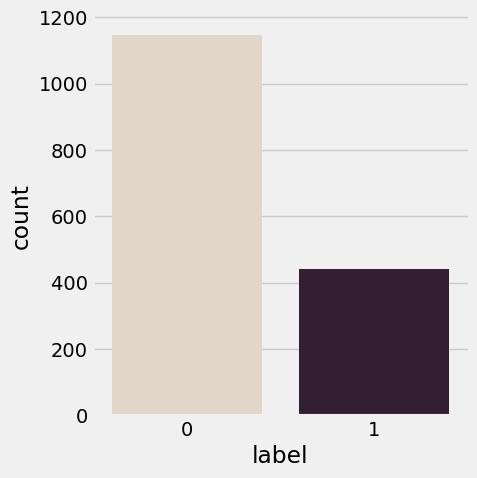

In [6]:
sns.catplot(x="label", kind="count", palette="ch:.25", data=train)

In [7]:
print(train['label'].value_counts())
print(train['label'].value_counts(normalize=True))

label
0    1148
1     441
Name: count, dtype: int64
label
0    0.722467
1    0.277533
Name: proportion, dtype: float64


## Feature Engineering

This cell is for feature engineering and specifically storing dictionaries of words that provide signal to determine each class. If you want to see what is helping the model and what is hurting the model run the cell at the bottom of the notebook. 

The biggest improvement that could be made here is by increasing the hedge words to encompass more.

In [47]:
import textstat
from collections import Counter
import numpy as np

# Medical / hedging vocabulary lists
HEDGE_WORDS = {
     'may', 'might', 'could', 'suggest', 'recommend', 'consider',
     'typically', 'generally', 'usually', 'often', 'sometimes',
     'consult', 'physician', 'doctor', 'specialist', 'diagnosed',
     'approximately', 'evidence', 'research', 'studies', 'clinical',
     'prescribed', 'monitored', 'evaluated', 'assessed', 'indicated',
     'contraindicated', 'advised', 'caution', 'warning', 'potential'
}


MEDICAL_TERMS = {
    'mg', 'dosage', 'symptoms', 'diagnosis', 'treatment', 'prescription',
    'chronic', 'acute', 'therapy', 'medication', 'dose', 'contraindicated',
    'clinical', 'patient', 'condition', 'syndrome', 'disorder', 'adverse',
    'efficacy', 'prognosis', 'inflammation', 'pathology', 'etiology',
    'hypertension', 'diabetes', 'insulin', 'antibiotics', 'ibuprofen',
    'acetaminophen', 'inflammation', 'infection', 'antibiotic', 'vaccine',
    'surgery', 'sedation', 'anesthesia', 'biopsy', 'sutures', 'fracture',
    'hemorrhage', 'artery', 'vein', 'platelet', 'hemoglobin', 'cortisol',
    'testosterone', 'estrogen', 'thyroid', 'adrenal', 'pancreas', 'liver',
    'kidney', 'neurological', 'psychiatric', 'cardiovascular', 'respiratory'
}

CAUTION_PHRASES = {
    'consult a doctor', 'see a physician', 'seek medical',
    'medical advice', 'not a substitute', 'talk to your doctor',
    'not medical advice', 'see a doctor', 'healthcare provider',
    'medical professional', 'licensed physician', 'board certified',
    'clinical studies', 'peer reviewed', 'evidence based'
}

# INFORMAL_MARKERS = {
#     'cant', 'wont', 'didnt', 'isnt', 'wasnt', 'wouldnt', 'couldnt',
#     'gonna', 'wanna', 'gotta', 'kinda', 'sorta',
#     'nope', 'yep', 'lol', 'omg', 'idk', 'tbh', 'imo'
# }

def extract_features(text):
    tokens    = text.lower().split()
    n         = max(len(tokens), 1)
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    n_sents   = max(len(sentences), 1)

    return {
        #Length
        #'char_count'          : len(text),
        'word_count'          : n,
        'sentence_count'      : n_sents,
        'avg_words_per_sent'  : n / n_sents,
        'avg_word_length'     : np.mean([len(t) for t in tokens]) if tokens else 0,
        'unique_word_ratio'   : len(set(tokens)) / n,

        #Sentence sophistication
        'has_parenthetical'   : int(bool(re.search(r'\(.*?\)', text))),  # (e.g., like this)
        'has_dosage_pattern'  : int(bool(re.search(r'\d+\s*mg|\d+\s*ml', text.lower()))),
        'has_percentage'      : int(bool(re.search(r'\d+\s*%', text))),
        #'has_citation_pattern': int(bool(re.search(r'study|research|published|journal', text.lower()))),

        #Readability (experts write more complex prose)
        'flesch_reading_ease' : textstat.flesch_reading_ease(text),
        'flesch_kincaid_grade': textstat.flesch_kincaid_grade(text),
        'gunning_fog'         : textstat.gunning_fog(text),

        #Formality signals
        'uppercase_ratio'     : sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'avg_sentence_length' : np.mean([len(s.split()) for s in sentences]) if sentences else 0,

        #Medical vocabulary
        'medical_term_count'  : sum(1 for t in tokens if t in MEDICAL_TERMS),
        'medical_term_ratio'  : sum(1 for t in tokens if t in MEDICAL_TERMS) / n,

        #Hedging (experts hedge, non-experts are overconfident)
        'hedge_count'         : sum(1 for t in tokens if t in HEDGE_WORDS),
        'hedge_ratio'         : sum(1 for t in tokens if t in HEDGE_WORDS) / n,

        #Caution phrases (very strong expert signal)
        'has_caution_phrase'  : int(any(p in text.lower() for p in CAUTION_PHRASES)),

        #Structure signals
        'has_numbered_list'   : int(bool(re.search(r'\b\d+[\.\)]\s', text))),
        'has_bullets'         : int(bool(re.search(r'^\s*[-•*]', text, re.MULTILINE))),
        'exclamation_count'   : text.count('!'),
        'question_count'      : text.count('?'),
        'comma_ratio'         : text.count(',') / n,

        #Negation (experts use precise negations)
        'negation_count'      : sum(1 for t in tokens if t in
                                    {'not','never','no','neither','nor','without'}),
        
        #Non-expert signals (negative features)
        'has_slang'           : int(any(w in text.lower().split() for w in
                                    {'lol', 'omg', 'wtf', 'tbh', 'idk', 'imo', 'ngl'})),
        'has_first_person_casual': int(bool(re.search(r'\bi feel\b|\bi think\b|\bi believe\b', text.lower()))),
        
        'short_sentence_ratio' : sum(1 for s in sentences 
                             if len(s.split()) < 5) / n_sents,

        #'informal_marker_ratio' : sum(1 for t in tokens if t in INFORMAL_MARKERS) / n,
        #'long_word_ratio' : sum(1 for t in tokens if len(t) > 6) / n,
    }

train_feats = pd.DataFrame([extract_features(t) for t in train['pr_answer']])
test_feats  = pd.DataFrame([extract_features(t) for t in test['pr_answer']])
kaggle_feats = pd.DataFrame([extract_features(t) for t in kaggle['pr_answer']])

# ML Pipeline

This cell contains a full pipeline that reruns the data cleaning, index alignment, and feature engineering end to end. It also searches for the optimal C value and prints real time results. Please try not to make extensive changes to this pipeline. If something breaks it will be hard to reconfig.

If you have already found the optimal C value and you are only making small tweaks, just use the cell below the pipeline. It will run much faster.

In [48]:
#ML pipeline
train = pd.read_csv('train_RateMyAnswer.csv', sep='|')
test  = pd.read_csv('test_RateMyAnswer.csv',  sep='|')
kaggle = pd.read_csv('kaggle_RateMyAnswer.csv', sep='|')

#clean bytes
def clean_byte_string(text):
    text = str(text)
    if text.startswith("b'") or text.startswith('b"'):
        text = text[2:-1]
    text = text.replace('\\n', ' ').replace('\\t', ' ').replace("\\'", "'")
    return text

train['answer']  = train['answer'].apply(clean_byte_string)
test['answer']   = test['answer'].apply(clean_byte_string)
kaggle['answer'] = kaggle['answer'].apply(clean_byte_string)

print("Train sample:", train['answer'].iloc[0][:80])
print("Kaggle sample:", kaggle['answer'].iloc[0][:80])

train['pr_answer']  = train['answer'].apply(preprocess)
test['pr_answer']   = test['answer'].apply(preprocess)
kaggle['pr_answer'] = kaggle['answer'].apply(preprocess)

#feature engineer
train_feats  = pd.DataFrame([extract_features(t) for t in train['pr_answer']])
test_feats   = pd.DataFrame([extract_features(t) for t in test['pr_answer']])
kaggle_feats = pd.DataFrame([extract_features(t) for t in kaggle['pr_answer']])

#TF-IDF
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 3), max_features=20000,
    sublinear_tf=True, min_df=1,
    strip_accents='unicode', analyzer='word'
)
tfidf_char = TfidfVectorizer(
    ngram_range=(2, 6), max_features=20000,
    sublinear_tf=True, min_df=1, analyzer='char_wb'
)

X_train_word = tfidf_word.fit_transform(train['pr_answer'])
X_train_char = tfidf_char.fit_transform(train['pr_answer'])

X_test_word  = tfidf_word.transform(test['pr_answer'])
X_test_char  = tfidf_char.transform(test['pr_answer'])

X_kaggle_word = tfidf_word.transform(kaggle['pr_answer'])
X_kaggle_char = tfidf_char.transform(kaggle['pr_answer'])

#scale
scaler = MaxAbsScaler()
train_feats_scaled  = scaler.fit_transform(train_feats.values)
test_feats_scaled   = scaler.transform(test_feats.values)
kaggle_feats_scaled = scaler.transform(kaggle_feats.values)

#combine
X_train_full = hstack([X_train_word, X_train_char, csr_matrix(train_feats_scaled)])
X_test_full  = hstack([X_test_word,  X_test_char,  csr_matrix(test_feats_scaled)])
X_kaggle     = hstack([X_kaggle_word, X_kaggle_char, csr_matrix(kaggle_feats_scaled)])

y_train = train['label'].values
print(f"\nAll matrices built")
print(f"   Train : {X_train_full.shape}")
print(f"   Kaggle: {X_kaggle.shape}")

# Step 8: C search on clean data
print("\n C search on clean data...\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# Phase 1 search
print("Phase 1...")
for C in [50.0, 100.0, 200.0, 250.0, 275.0, 500.0, 550.0, 600.0]:
    model = LogisticRegression(
        C=C, penalty='l2', class_weight='balanced',
        solver='saga', max_iter=4500, tol=1e-4, n_jobs=-1
    )
    
    scores = cross_val_score(
        model, X_train_full, y_train,
        cv=cv,            
        scoring='neg_log_loss'
    )
    
    mean_loss = -scores.mean()
    results[C] = mean_loss
    
    print(f"  C={C:<6} | CV Log-Loss: {mean_loss:.4f} ± {scores.std():.4f}")

best_C = min(results, key=results.get)
print(f"\nBest C found: {best_C} with Log-Loss: {results[best_C]:.4f}")

#extremely fine-tuned
final_model = LogisticRegression(
    C=275.0,
    penalty='l2',
    class_weight='balanced',
    solver='saga',
    max_iter=4500,
    tol=1e-4,
    n_jobs=-1
)
final_model.fit(X_train_full, y_train)

kaggle['Expected'] = final_model.predict_proba(X_kaggle)[:, 1]
kaggle['Expected'] = np.clip(kaggle['Expected'], 1e-7, 1 - 1e-7)

print(f"\nMin prob : {kaggle['Expected'].min():.4f}")
print(f"Max prob : {kaggle['Expected'].max():.4f}")
print(f"Mean prob: {kaggle['Expected'].mean():.4f}")

kaggle[['index', 'Expected']].to_csv('to_Kaggle_RMA.csv', index=False)

Train sample: When other methods dont seem to work, see a psychologist for training in progres
Kaggle sample: first find a good man to help you raise your children.  always be re sponsible a

All matrices built
   Train : (1589, 40027)
   Kaggle: (496, 40027)

 C search on clean data...

Phase 1...
  C=50.0   | CV Log-Loss: 0.0723 ± 0.0115
  C=100.0  | CV Log-Loss: 0.0703 ± 0.0130
  C=200.0  | CV Log-Loss: 0.0694 ± 0.0144
  C=250.0  | CV Log-Loss: 0.0693 ± 0.0147
  C=275.0  | CV Log-Loss: 0.0690 ± 0.0151
  C=500.0  | CV Log-Loss: 0.0695 ± 0.0161
  C=550.0  | CV Log-Loss: 0.0695 ± 0.0164
  C=600.0  | CV Log-Loss: 0.0696 ± 0.0164

Best C found: 275.0 with Log-Loss: 0.0690

Min prob : 0.0000
Max prob : 1.0000
Mean prob: 0.2872


## Run this cell to make quick tweaks to the model without having to run the above pipeline.

If you make tweaks or add new features, its a smart idea to refind the optimal C value. For example, a C_value of 275 gave us our best score of 0.4556, but I added a new feature and got a score of 0.04080 with a C_value of 250.

In [49]:
#extremely fine-tuned
final_model = LogisticRegression(
    #C=275.0,
    #C=550.0,
    C=280.0,
    penalty='l2',
    class_weight='balanced',
    solver='saga',
    max_iter=4500,
    tol=1e-4,
    n_jobs=-1
)

final_model.fit(X_train_full, y_train)

kaggle['Expected'] = final_model.predict_proba(X_kaggle)[:, 1]
kaggle['Expected'] = np.clip(kaggle['Expected'], 1e-7, 1 - 1e-7)

print(f"Min  : {kaggle['Expected'].min():.4f}")
print(f"Max  : {kaggle['Expected'].max():.4f}")
print(f"Mean : {kaggle['Expected'].mean():.4f}")

kaggle[['index', 'Expected']].to_csv('to_Kaggle_RMA.csv', index=False)
print("Model Extremely Fine-Tuned")

Min  : 0.0000
Max  : 1.0000
Mean : 0.2872
Model Extremely Fine-Tuned


# Assessing Accuracy

These cells have a modified confusion matrix and ROC AUC curve that work for a logistic regression model. This works well because this is still inherently a binary classification problem.

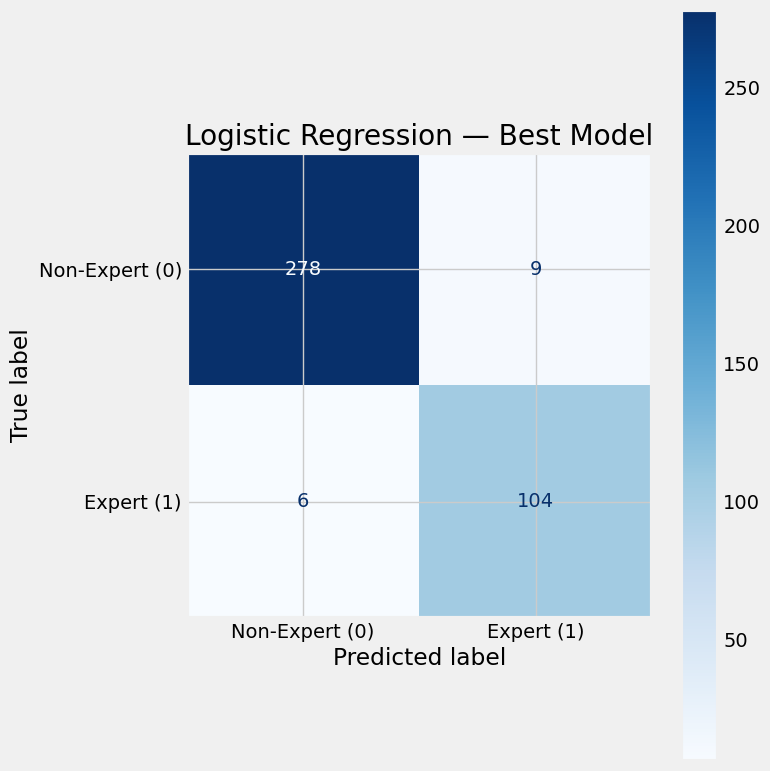

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = final_model.predict_proba(X_test_full)[:, 1]
y_pred       = (y_pred_probs >= 0.5).astype(int)
Y_test = test['label'].values

confusionMatrix = confusion_matrix(Y_test, y_pred)

plt.rcParams['figure.figsize'] = (8, 8)
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix,
    display_labels=['Non-Expert (0)', 'Expert (1)']
)
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Best Model')
plt.tight_layout()
plt.show()

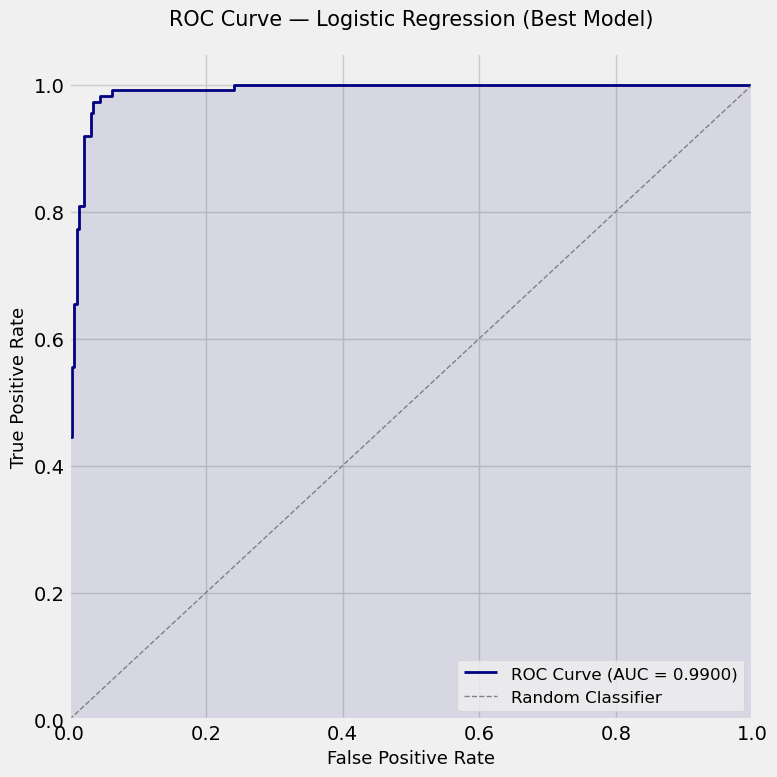

AUC Score: 0.9900


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

y_pred_probs = final_model.predict_proba(X_test_full)[:, 1]
Y_test = test['label'].values

fpr, tpr, thresholds = roc_curve(Y_test, y_pred_probs, pos_label=1)
lr_auc = roc_auc_score(Y_test, y_pred_probs)

plt.rcParams['figure.figsize'] = (8, 8)
plt.plot(fpr, tpr, color='navy', lw=2, label=f'ROC Curve (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='navy')  # shaded area under curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title(f'ROC Curve — Logistic Regression (Best Model)', fontsize=15, pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUC Score: {lr_auc:.4f}")

# Logistic Regression Coefficients

This cell is to pull the coefficients for the model to see what is helping or hurting the model. Just as a note, the more features you add, remove, or adjust, means the optimal C value might change as well.

In [52]:
#Extract features
word_features = tfidf_word.get_feature_names_out()
char_features = tfidf_char.get_feature_names_out()
hand_features = train_feats.columns.tolist()
all_features  = np.concatenate([word_features, char_features, hand_features])

coefs = final_model.coef_[0]

#Top expert signals
top_expert = pd.Series(coefs, index=all_features).nlargest(20)
print("Top EXPERT signals:")
print(top_expert.to_string())

#Top non-expert signals
top_nonexpert = pd.Series(coefs, index=all_features).nsmallest(20)
print("\nTop NON-EXPERT signals:")
print(top_nonexpert.to_string())

Top EXPERT signals:
hedge_ratio           7.525435
medical_term_ratio    5.792570
may                   4.540331
hedge_count           3.810178
the                   3.736978
of                    3.367823
of the                3.281101
that you              2.787150
in the                2.705261
due                   2.571569
due to                2.557799
take care             2.459356
avg_word_length       2.407769
is                    2.357101
there is              2.310526
case                  2.233158
advise                2.229985
you to                2.176631
an                    2.157670
pain                  2.144780

Top NON-EXPERT signals:
short_sentence_ratio      -8.415606
unique_word_ratio         -5.026566
sentence_count            -4.006941
comma_ratio               -3.964579
flesch_reading_ease       -3.570813
exclamation_count         -3.067920
has_numbered_list         -2.921368
it                        -2.849931
question_count            -2.748292
has_first_p

# Pickle Pre-processed Text and Model Results

This is incase you want to save your model in this session so that you do not have to rerun everything again

In [14]:
import pickle
import joblib

joblib.dump(tfidf_word, 'tfidf_word.pkl')
joblib.dump(tfidf_char, 'tfidf_char.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(final_model, 'final_model.pkl')

from scipy.sparse import save_npz
save_npz('X_train_full.npz', X_train_full)
save_npz('X_test_full.npz',  X_test_full)
save_npz('X_kaggle.npz',     X_kaggle)

np.save('y_train.npy', y_train)

train_feats.to_csv('train_feats.csv', index=False)
test_feats.to_csv('test_feats.csv',   index=False)
kaggle_feats.to_csv('kaggle_feats.csv', index=False)

print("All objects saved")

All objects saved
